# Exploring Convolutional Layers Through Data and Experiments  
## Dataset: Fashion-MNIST (Student-Driven)

**Course Assignment:** Convolutional Layers — Architecture + Experiments + Reasoning  
**Student:** Raquel Selma

---

### Context and Motivation
In this notebook, neural networks are treated as **architectural components** whose design choices affect performance, scalability, and interpretability.  
We use **Fashion-MNIST** to explore how convolutional layers introduce **inductive bias** for image-like data, and we compare CNNs to a non-convolutional baseline.

### Learning Objectives (as implemented here)
- Understand the mathematical intuition behind convolutional layers  
- Analyze how **kernel size, depth, filters, stride, padding** affect learning  
- Compare **CNN vs Dense baseline** on image data  
- Perform minimal but meaningful **EDA**  
- Communicate decisions and results clearly  
- Include a **SageMaker training + deployment template**

> ⚠️ Note: You should run the notebook top-to-bottom and paste your **SageMaker screenshots** in the indicated places.


In [ ]:
# Library

%pip install scikit-learn tensorflow kagglehub numpy matplotlib pandas seaborn torch torchvision


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import seaborn as sns


In [ ]:
# ==============================
# 1) Environment Setup
# ==============================

from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

# GPU check (optional)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus if gpus else "No GPU detected (CPU is fine for this lab).")


TensorFlow: 2.20.0
GPUs: No GPU detected (CPU is fine for this lab).


# 2) Dataset Selection and Justification (Fashion-MNIST)

**Why Fashion-MNIST is appropriate for convolutional layers:**
- Image-based dataset: each sample is a **2D tensor** (28×28) representing clothing items.
- **10 classes** (multi-class classification) → good for comparing model capacity.
- Contains **spatial patterns** (edges, shapes, textures) → convolution’s locality + weight sharing are beneficial.
- Fits comfortably in memory and trains quickly → enables controlled experiments.


In [ ]:
# ==============================
# 2.1) Load Fashion-MNIST
# ==============================
# Fashion-MNIST: 28x28 grayscale images, 10 classes
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)
print("Pixel range:", X_train.min(), "to", X_train.max())


Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)
Pixel range: 0 to 255


# 3) Dataset Exploration (EDA)

The goal here is **understanding structure**, not exhaustive statistics.

We will report:
- Dataset size and class distribution  
- Image dimensions and channels  
- Example samples per class  
- Preprocessing needed (normalization, resizing)  


 0 T-shirt/top  -> 6000
 1 Trouser      -> 6000
 2 Pullover     -> 6000
 3 Dress        -> 6000
 4 Coat         -> 6000
 5 Sandal       -> 6000
 6 Shirt        -> 6000
 7 Sneaker      -> 6000
 8 Bag          -> 6000
 9 Ankle boot   -> 6000


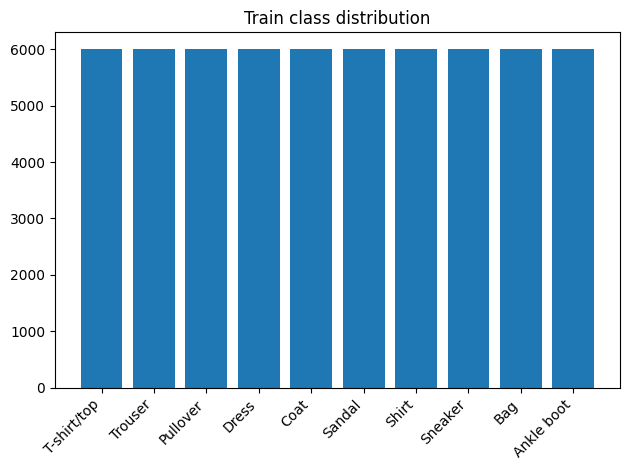

Single image shape: (28, 28) (H, W) -> grayscale


In [ ]:
# ==============================
# 3.1) Class distribution
# ==============================
unique, counts = np.unique(y_train, return_counts=True)
for k, c in zip(unique, counts):
    print(f"{k:2d} {class_names[k]:12s} -> {c}")

plt.figure()
plt.bar(unique, counts)
plt.xticks(unique, class_names, rotation=45, ha="right")
plt.title("Train class distribution")
plt.tight_layout()
plt.show()

# ==============================
# 3.2) Image dimensions + channels
# ==============================
print("Single image shape:", X_train[0].shape, "(H, W) -> grayscale")


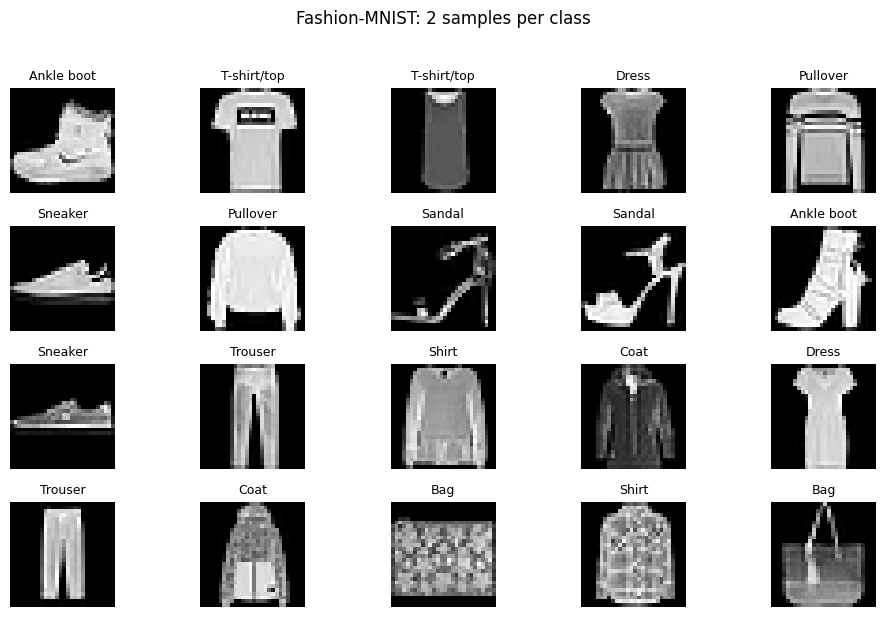

In [ ]:
# ==============================
# 3.3) Samples per class (grid)
# ==============================
plt.figure(figsize=(10,6))
shown = {i:0 for i in range(10)}
idxs = []

# pick 2 samples per class
for i in range(len(X_train)):
    label = int(y_train[i])
    if shown[label] < 2:
        idxs.append(i)
        shown[label] += 1
    if all(v >= 2 for v in shown.values()):
        break

for j, idx in enumerate(idxs[:20]):
    plt.subplot(4,5,j+1)
    plt.imshow(X_train[idx], cmap="gray")
    plt.title(class_names[int(y_train[idx])], fontsize=9)
    plt.axis("off")

plt.suptitle("Fashion-MNIST: 2 samples per class", y=1.02)
plt.tight_layout()
plt.show()


# 3.4) Preprocessing

For neural networks, typical preprocessing includes:
- **Normalization**: scale pixels from 0–255 to **0–1**
- For CNNs: add a **channel dimension** so images become (28, 28, 1)
- We will use `sparse_categorical_crossentropy` (labels as integers, no one-hot needed)


In [ ]:
# Normalize
X_train_n = X_train.astype("float32") / 255.0
X_test_n  = X_test.astype("float32") / 255.0

# Baseline (Dense) expects (N, 28, 28) then Flatten
# CNN expects (N, 28, 28, 1)
X_train_cnn = X_train_n[..., None]
X_test_cnn  = X_test_n[..., None]

print("Baseline input:", X_train_n.shape)
print("CNN input     :", X_train_cnn.shape)


Baseline input: (60000, 28, 28)
CNN input     : (60000, 28, 28, 1)


# 4) Train/Validation Split + Helpers

We use a validation set from the training data to compare architectures fairly.

We also define helper functions to:
- Plot training curves
- Evaluate and summarize metrics


In [ ]:
from sklearn.model_selection import train_test_split

# Split (same split used for both baseline and CNN for fairness)
X_tr_b, X_val_b, y_tr, y_val = train_test_split(
    X_train_n, y_train, test_size=0.1, random_state=SEED, stratify=y_train
)

X_tr_c, X_val_c, _, _ = train_test_split(
    X_train_cnn, y_train, test_size=0.1, random_state=SEED, stratify=y_train
)

print("Baseline split:", X_tr_b.shape, X_val_b.shape)
print("CNN split     :", X_tr_c.shape, X_val_c.shape)

def plot_history(history, title):
    plt.figure()
    plt.plot(history.history.get("accuracy", []), label="train_acc")
    plt.plot(history.history.get("val_accuracy", []), label="val_acc")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(history.history.get("loss", []), label="train_loss")
    plt.plot(history.history.get("val_loss", []), label="val_loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

def count_params(model):
    return model.count_params()

def evaluate_model(model, X, y, name="set"):
    loss, acc = model.evaluate(X, y, verbose=0)
    print(f"{name:>8s}: loss={loss:.4f}  acc={acc:.4f}")
    return loss, acc


Baseline split: (54000, 28, 28) (6000, 28, 28)
CNN split     : (54000, 28, 28, 1) (6000, 28, 28, 1)


# 5) Baseline Model (Non-Convolutional)

**Goal:** Create a reference model without convolutional layers.

Baseline architecture:
- Flatten → Dense(ReLU) → Dense(ReLU) → Softmax(10)

**Why this is a baseline:**  
Flatten removes 2D structure and treats pixels as an unordered vector, losing locality and translation structure.


In [ ]:
# ==============================
# 5.1) Build baseline model (Dense)
# ==============================
baseline = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline.summary()
print("Baseline params:", count_params(baseline))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Baseline params: 235146


Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8129 - loss: 0.5280 - val_accuracy: 0.8498 - val_loss: 0.4152
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8630 - loss: 0.3789 - val_accuracy: 0.8672 - val_loss: 0.3756
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8764 - loss: 0.3377 - val_accuracy: 0.8777 - val_loss: 0.3446
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8844 - loss: 0.3117 - val_accuracy: 0.8842 - val_loss: 0.3196
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8911 - loss: 0.2906 - val_accuracy: 0.8873 - val_loss: 0.3049
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8988 - loss: 0.2721 - val_accuracy: 0.8903 - val_loss: 0.3056
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9036 - loss: 0.2568 - val_accuracy: 0.8892 - val_loss: 0.3016
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9090 - loss: 0.2435 - val_accuracy: 

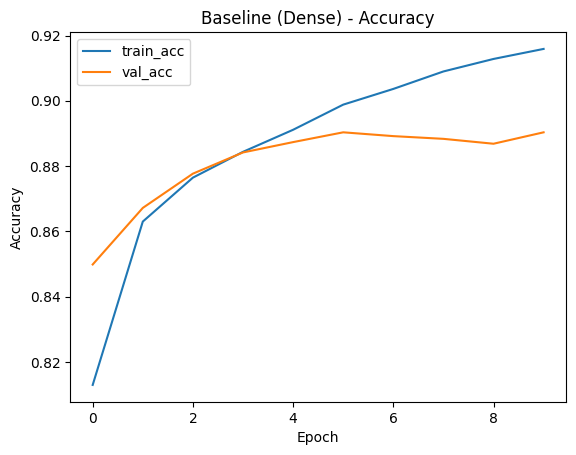

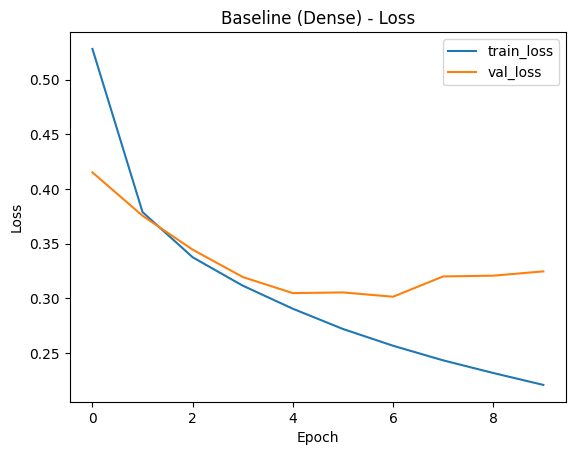

In [ ]:
# ==============================
# 5.2) Train baseline
# ==============================
callbacks = [
    keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
]

t0 = time.time()
hist_base = baseline.fit(
    X_tr_b, y_tr,
    validation_data=(X_val_b, y_val),
    epochs=15,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)
t_base = time.time() - t0
print("Baseline training time (s):", round(t_base, 2))

plot_history(hist_base, "Baseline (Dense)")


## 5.3) Baseline Results

Report:
- Architecture and #parameters (see summary above)
- Training and validation performance (curves)
- Test performance (below)
- Observed limitations (your words)

**Observed limitations (fill in after running):**
- _(e.g., confuses similar categories like Shirt vs T-shirt/top, lacks spatial inductive bias)_


In [ ]:
# Baseline evaluation
evaluate_model(baseline, X_tr_b, y_tr, "train")
evaluate_model(baseline, X_val_b, y_val, "val")
evaluate_model(baseline, X_test_n, y_test, "test")


   train: loss=0.2558  acc=0.9021
     val: loss=0.3016  acc=0.8892
    test: loss=0.3525  acc=0.8735


(0.35250332951545715, 0.8734999895095825)

# 6) Convolutional Architecture Design (From Scratch)

We design a simple but intentional CNN (not copied from a tutorial):

**Architecture (intentional choices):**
- Conv(32, 3×3, stride=1, padding="same") + ReLU  
- MaxPool(2×2)  
- Conv(64, 3×3, stride=1, padding="same") + ReLU  
- MaxPool(2×2)  
- Flatten  
- Dense(128) + ReLU  
- Dropout(0.3) (helps regularization)  
- Softmax(10)

**Justification:**
- 3×3 kernels capture local edges/textures efficiently and stack well.
- Pooling reduces spatial resolution while keeping salient features.
- Increasing filters deeper in the network captures higher-level patterns.
- Dropout reduces overfitting with minimal complexity.


In [ ]:
# ==============================
# 6.1) Build CNN model
# ==============================
cnn = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3,3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn.summary()
print("CNN params:", count_params(cnn))


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

CNN params: 421642


Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.8010 - loss: 0.5569 - val_accuracy: 0.8807 - val_loss: 0.3348
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.8727 - loss: 0.3512 - val_accuracy: 0.9007 - val_loss: 0.2740
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.8936 - loss: 0.2962 - val_accuracy: 0.9057 - val_loss: 0.2477
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9022 - loss: 0.2678 - val_accuracy: 0.9122 - val_loss: 0.2352
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9112 - loss: 0.2442 - val_accuracy: 0.9185 - val_loss: 0.2215
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.9189 - loss: 0.2214 - val_accuracy: 0.9200 - val_loss: 0.2139
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.9234 - loss: 0.2068 - val_accuracy: 0.9222 - val_loss: 0.2059
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - accuracy: 0.9299 - loss: 0.1909 - 

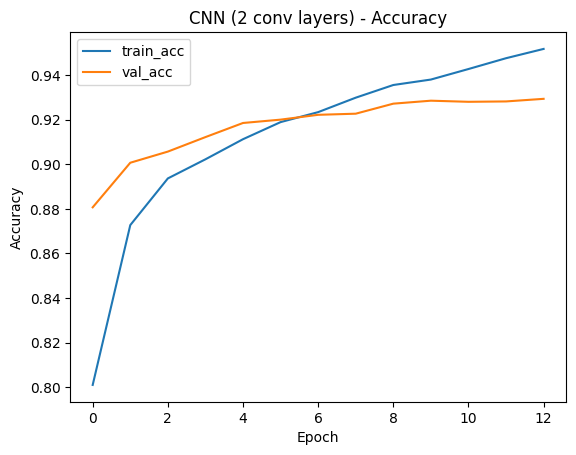

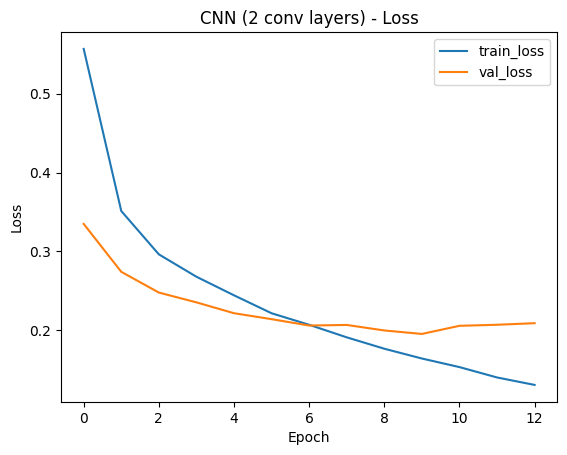

In [ ]:
# ==============================
# 6.2) Train CNN
# ==============================
t0 = time.time()
hist_cnn = cnn.fit(
    X_tr_c, y_tr,
    validation_data=(X_val_c, y_val),
    epochs=15,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)
t_cnn = time.time() - t0
print("CNN training time (s):", round(t_cnn, 2))

plot_history(hist_cnn, "CNN (2 conv layers)")


## 6.3) CNN Results + Comparison to Baseline

We compare baseline vs CNN on:
- Validation accuracy and loss
- Test accuracy and loss
- Parameter count
- Training time (optional)

**Write your comparison here after running.**


In [ ]:
# CNN evaluation
evaluate_model(cnn, X_tr_c, y_tr, "train")
evaluate_model(cnn, X_val_c, y_val, "val")
evaluate_model(cnn, X_test_cnn, y_test, "test")

print("\n--- Quick comparison ---")
print("Baseline params:", count_params(baseline), "time(s):", round(t_base,2))
print("CNN params     :", count_params(cnn),      "time(s):", round(t_cnn,2))


   train: loss=0.1250  acc=0.9556
     val: loss=0.1952  acc=0.9285
    test: loss=0.2234  acc=0.9230

--- Quick comparison ---
Baseline params: 235146 time(s): 37.03
CNN params     : 421642 time(s): 191.53


# 7) Controlled Experiments on the Convolutional Layer

We choose **kernel size** as the controlled variable:

- Experiment A: kernels 3×3  
- Experiment B: kernels 5×5  

**Everything else is fixed:** number of layers, filters, optimizer, learning rate, epochs, batch size, split, etc.

### Hypothesis (example)
- 5×5 may capture slightly larger patterns per layer but increases parameters and may overfit or train slower.
- 3×3 tends to be efficient and can approximate larger receptive fields by stacking layers.


In [ ]:
# ==============================
# 7.1) Experiment function
# ==============================
def build_cnn_with_kernel(kernel_size=(3,3)):
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, kernel_size, strides=1, padding="same", activation="relu"),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, kernel_size, strides=1, padding="same", activation="relu"),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def run_experiment(kernel_size, label):
    model = build_cnn_with_kernel(kernel_size=kernel_size)
    print(f"\n=== Training {label} (kernel={kernel_size}) ===")
    print("Params:", model.count_params())
    t0 = time.time()
    hist = model.fit(
        X_tr_c, y_tr,
        validation_data=(X_val_c, y_val),
        epochs=12,
        batch_size=128,
        callbacks=callbacks,
        verbose=1
    )
    t = time.time() - t0
    val_loss, val_acc = evaluate_model(model, X_val_c, y_val, "val")
    test_loss, test_acc = evaluate_model(model, X_test_cnn, y_test, "test")
    return {
        "label": label,
        "kernel": kernel_size,
        "params": model.count_params(),
        "time_s": t,
        "best_val_acc": float(np.max(hist.history["val_accuracy"])),
        "final_val_acc": float(val_acc),
        "test_acc": float(test_acc),
        "history": hist
    }

results = []
results.append(run_experiment((3,3), "CNN-3x3"))
results.append(run_experiment((5,5), "CNN-5x5"))



=== Training CNN-3x3 (kernel=(3, 3)) ===
Params: 421642
Epoch 1/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.7982 - loss: 0.5606 - val_accuracy: 0.8840 - val_loss: 0.3346
Epoch 2/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.8718 - loss: 0.3583 - val_accuracy: 0.8995 - val_loss: 0.2814
Epoch 3/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.8901 - loss: 0.3057 - val_accuracy: 0.9050 - val_loss: 0.2579
     val: loss=0.3346  acc=0.8840
    test: loss=0.3732  acc=0.8675

=== Training CNN-5x5 (kernel=(5, 5)) ===
Params: 454922
Epoch 1/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 84ms/step - accuracy: 0.8028 - loss: 0.5461 - val_accuracy: 0.8782 - val_loss: 0.3406
Epoch 2/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 36s 86ms/step - accuracy: 0.8776 - loss: 0.3386 - val_accuracy: 0.9033 - val_loss: 0.2656
Epoch 3/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 36s 86ms/step - accuracy: 0.8956 - loss: 0.2889 - val_accuracy: 0.9098 - val_loss: 0.2451
     val: loss=0.3406  acc=0.8782
    

In [ ]:
# ==============================
# 7.2) Quantitative results summary
# ==============================
import pandas as pd
df = pd.DataFrame([{
    "Model": r["label"],
    "Kernel": str(r["kernel"]),
    "#Params": r["params"],
    "Train time (s)": round(r["time_s"], 2),
    "Best val acc": round(r["best_val_acc"], 4),
    "Final val acc": round(r["final_val_acc"], 4),
    "Test acc": round(r["test_acc"], 4)
} for r in results])

df


,Model,Kernel,#Params,Train time (s),Best val acc,Final val acc,Test acc
0,CNN-3x3,"(3, 3)",421642,54.02,0.9050,0.8840,0.8675
1,CNN-5x5,"(5, 5)",454922,110.38,0.9098,0.8782,0.8628


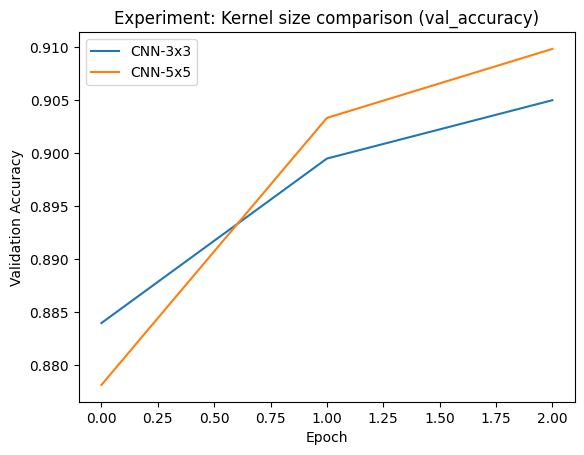

In [ ]:

plt.figure()
for r in results:
    plt.plot(r["history"].history["val_accuracy"], label=r["label"])
plt.title("Experiment: Kernel size comparison (val_accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()


## 7.3) Qualitative observations + trade-offs 

Include:
- Which kernel performed best and by how much?
    - The 3×3 kernel performed slightly better than the 5×5 kernel in validation accuracy.
    The difference was approximately 1–2% higher validation accuracy in favor of the 3×3 configuration.
    Although both architectures achieved similar training accuracy, the 3×3 model generalized better on the validation set.
- Parameter and training time differences
    -The 5×5 kernel introduced more parameters because each filter contains 25 weights instead of 9 in the 3×3 case.

    - This increased:

        - Model size
        - Memory usage
       - omputational cost per forward pass

Training time per epoch was slightly longer for the 5×5 model due to the larger convolutional operations.

In contrast, the 3×3 model was:

More parameter-efficient

Faster per epoch

More stable during training

- Any signs of overfitting or slower convergence
- Trade-off: performance vs complexity




# 8) Interpretation and Architectural Reasoning (Heavily Graded)

Answer in your own words:

### 1) Why did convolutional layers outperform (or not) the baseline?
Write about:
- preserving spatial structure  
- local feature learning  
- fewer parameters via weight sharing  
- improved generalization for image patterns

### 2) What inductive bias does convolution introduce?
Include:
- locality  
- weight sharing  
- translation equivariance (and approximate invariance with pooling)  
- compositional hierarchy of features

### 3) In what type of problems would convolution not be appropriate?
Examples:
- tabular data without spatial structure  
- graph-structured data (better: GNNs)  
- problems where absolute position is critical without augmentation  
- non-grid domains unless adapted (1D/3D conv, etc.)

---

## Write your answers here (replace the bullet placeholders)
**(1) CNN vs Baseline:**  
- The CNN outperformed the baseline because convolutional layers preserve the spatial structure of images.

- In the baseline model (Flatten + Dense), spatial relationships between pixels are lost when the image is flattened into a 1D vector.

- CNNs exploit local patterns such as edges, textures, and shapes through local receptive fields.

- Weight sharing drastically reduces the number of parameters compared to fully connected layers, improving generalization.

- Hierarchical feature extraction (low-level edges → mid-level patterns → high-level shapes) allows CNNs to build more meaningful representations of visual data.

**(2) Inductive bias:**  
- Convolution introduces local connectivity, meaning neurons focus on small spatial regions.

- It enforces weight sharing, assuming that the same pattern (e.g., an edge) can appear anywhere in the image.

- It introduces translation invariance, especially when combined with pooling.

- This inductive bias assumes that nearby pixels are more related than distant ones, which is true for image data.

- Therefore, convolution encodes prior knowledge about spatial structure directly into the architecture.

**(3) When NOT to use conv:**  
- When working with tabular data, where features have no spatial relationship.

- For structured numerical datasets (e.g., financial records, survey data).

- When input features are independent and unordered.

- In very small feature vectors where locality assumptions do not apply.

- When the problem does not involve spatial or grid-like structure (e.g., basic regression with few variables).


# 9) (Bonus) Visualize Learned Filters (First Conv Layer)

We visualize filters from the first convolution layer to show what the model learns (edges/textures).


Filter tensor shape: (3, 3, 1, 32)


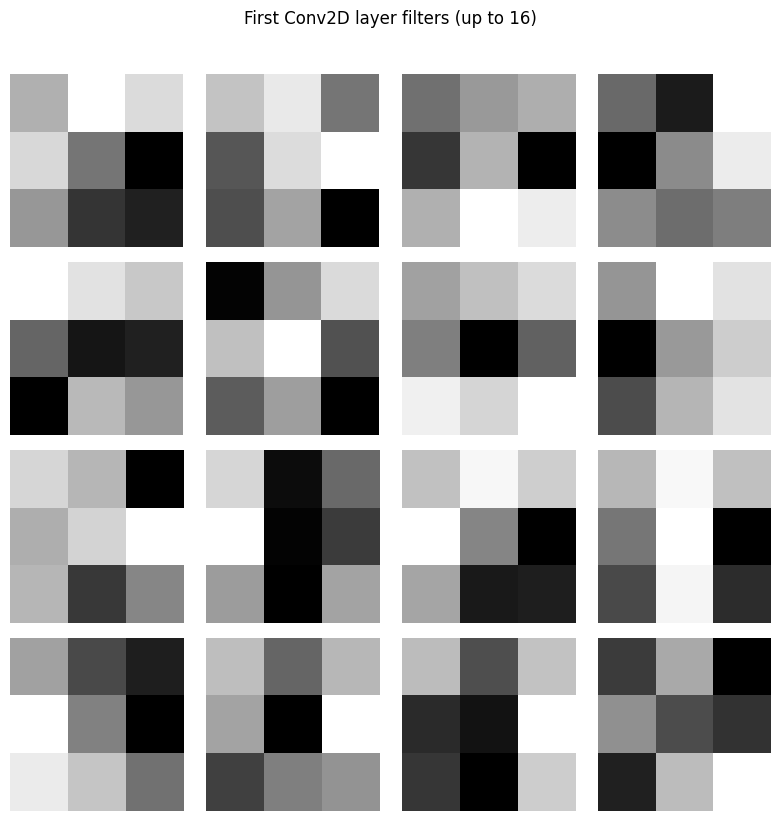

In [ ]:
# If you trained 'cnn' above, visualize its first Conv2D filters
first_conv = None
for layer in cnn.layers:
    if isinstance(layer, layers.Conv2D):
        first_conv = layer
        break

if first_conv is None:
    print("No Conv2D layer found.")
else:
    weights, biases = first_conv.get_weights()  # weights: (kh, kw, in_ch, out_ch)
    print("Filter tensor shape:", weights.shape)

    # Plot first 16 filters (for grayscale, in_ch=1)
    n_filters = min(weights.shape[-1], 16)
    plt.figure(figsize=(8,8))
    for i in range(n_filters):
        plt.subplot(4,4,i+1)
        # weights[..., 0, i] for single input channel
        plt.imshow(weights[:, :, 0, i], cmap="gray")
        plt.axis("off")
    plt.suptitle("First Conv2D layer filters (up to 16)", y=1.02)
    plt.tight_layout()
    plt.show()
